Import Libraries

Fase Inisialisasi: Mengimpor semua pustaka analisis data, ekstraksi teks, pemodelan, optimasi hiperparameter, dan visualisasi grafis.

In [952]:
# Cell 1: Import Library
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse

# Library Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import time

# Library Machine Learning & Pemisahan Data
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)

print("=== Semua library berhasil diimpor ===")

=== Semua library berhasil diimpor ===


FASE 1 — Data Collection

Mengakuisisi berkas mentah dari direktori, menyaring atribut url, melakukan penyeimbangan data secara acak (sampling 5.000 data per berkas), dan memberikan label biner target.

In [953]:
# Cell 2: [Fase 1 - Data Collection]

# 1. Memuat file dataset mentah
df_phish_raw = pd.read_csv('phising.csv')
df_legit_raw = pd.read_csv('legitimate.csv')

# 2. Mengambil 5.000 sampel secara acak (Random State = 12) agar data seimbang
df_phish_collected = df_phish_raw[['url']].sample(n=5000, random_state=12).reset_index(drop=True)
df_legit_collected = df_legit_raw[['url']].sample(n=5000, random_state=12).reset_index(drop=True)

# 3. Memberikan label target biner (1 = Phishing, 0 = Legitimate)
df_phish_collected['label'] = 1
df_legit_collected['label'] = 0

print("=== Fase 1: Data Collection Selesai ===")
print(f"Jumlah Data Phishing   : {df_phish_collected.shape[0]} baris")
print(f"Jumlah Data Legitimate : {df_legit_collected.shape[0]} baris")

=== Fase 1: Data Collection Selesai ===
Jumlah Data Phishing   : 5000 baris
Jumlah Data Legitimate : 5000 baris


/tmp/ipykernel_491/612023218.py:5: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df_legit_raw = pd.read_csv('legitimate.csv')


FASE 2 — Data Preprocessing (Cleaning & Aturan Ekstraksi)

Melakukan pembersihan data awal (menghapus duplikat URL, mengubah teks menjadi huruf kecil), mendefinisikan fungsi ekstraksi 8 fitur biner leksikal sesuai instruksi baku jurnal, dan membangun dataset terstruktur final.

In [954]:
# [Fase 2 - Data Preprocessing: Cleaning & Logika Fitur]

# 1. Fungsi Pembersihan Data (Cleaning & Remove Duplicate)
def clean_urls(df):
    df = df.copy()
    df['url'] = df['url'].astype(str).str.lower() # Mengubah menjadi lowercase
    df = df.drop_duplicates(subset=['url']).reset_index(drop=True) # Menghapus duplicate URL
    return df

df_phish_cleaned = clean_urls(df_phish_collected)
df_legit_cleaned = clean_urls(df_legit_collected)

# 2. Fungsi Ekstraksi 8 Fitur URL Sesuai Aturan Jurnal
def extract_8_features(url):
    features = {}
    url = str(url)
    parsed_url = urlparse(url)
    domain = parsed_url.netloc

    # Fitur 1: Menggunakan IP Address pada URL
    ip_pattern = r'(\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3})|(0x[0-9a-fA-F]+\.0x[0-9a-fA-F]+\.0x[0-9a-fA-F]+\.0x[0-9a-fA-F]+)|(^[a-fA-F0-9:]+$)'
    features['Using_IP'] = 1 if re.search(ip_pattern, url) else 0

    # Fitur 2: Terdapat simbol ‘@’ pada URL
    features['Have_At_Symbol'] = 1 if '@' in url else 0

    # Fitur 3: Memiliki URL yang panjang (lebih dari 54 karakter)
    features['Long_URL'] = 1 if len(url) >= 54 else 0

    # Fitur 4: Jumlah sub-page atau sub-domain ditandai dengan simbol ‘/’ (> 5 dianggap anomali)
    features['Count_Slash'] = 1 if url.count('/') > 5 else 0

    # Fitur 5: Redirection page menggunakan ‘//’ setelah indeks protokol ke-7
    features['Redirection_Double_Slash'] = 1 if url.rfind('//') > 7 else 0

    # Fitur 6: Terdapat http/https pada nama domain untuk mengelabui pengguna
    features['Http_Https_In_Domain'] = 1 if 'http' in domain or 'https' in domain else 0

    # Fitur 7: Menggunakan URL shortening services ‘TinyURL’ atau sejenisnya
    short_pattern = r'bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs'
    features['Tiny_URL'] = 1 if re.search(short_pattern, url) else 0

    # Fitur 8: Terdapat prefiks atau sufiks ‘-’ pada nama domain
    features['Prefix_Suffix_Domain'] = 1 if '-' in domain else 0

    return features

print("=== Fase 2: Aturan Preprocessing & Pembersihan Sukses Disusun ===")

=== Fase 2: Aturan Preprocessing & Pembersihan Sukses Disusun ===


FASE 2 — Data Preprocessing (Eksekusi Ekstraksi Fitur & Gabung)

Mengeksekusi proses ekstraksi fitur leksikal pada data yang telah dibersihkan, mengonversi struktur list menjadi DataFrame numerik biner, dan menggabungkannya secara vertikal.

In [955]:
# [Fase 2 - Data Preprocessing: Eksekusi Fitur & Integrasi]
print("Sedang mengekstrak fitur biner leksikal dari URL, mohon tunggu...")

# Ekstraksi dataset phishing
phish_feat_list = [extract_8_features(u) for u in df_phish_cleaned['url']]
df_phish_final = pd.DataFrame(phish_feat_list)
df_phish_final['label'] = 1

# Ekstraksi dataset legitimate
legit_feat_list = [extract_8_features(u) for u in df_legit_cleaned['url']]
df_legit_final = pd.DataFrame(legit_feat_list)
df_legit_final['label'] = 0

# Menggabungkan kedua dataset menjadi Dataset Final
df_dataset_final = pd.concat([df_phish_final, df_legit_final], ignore_index=True)

print("\n=== Fase 2: Selesai! Dataset Utama Berhasil Dibentuk ===")
print(f"Dimensi Dataset Final: {df_dataset_final.shape}")
df_dataset_final.head()

Sedang mengekstrak fitur biner leksikal dari URL, mohon tunggu...

=== Fase 2: Selesai! Dataset Utama Berhasil Dibentuk ===
Dimensi Dataset Final: (9997, 9)


,Using_IP,Have_At_Symbol,Long_URL,Count_Slash,Redirection_Double_Slash,Http_Https_In_Domain,Tiny_URL,Prefix_Suffix_Domain,label
0,0,0,1,0,0,0,0,1,1
1,0,0,1,1,0,0,0,0,1
2,0,0,0,0,0,0,1,0,1
3,0,0,1,0,0,0,0,0,1
4,0,0,0,0,0,0,1,0,1


FASE 3 — Data Exploration (EDA)

Melakukan eksplorasi data komprehensif (EDA) untuk memeriksa struktur dataset, null values, data duplikat hasil ekstraksi biner, sebaran label, hingga korelasi antar-fitur.

--- 1. Struktur Dataset & Tipe Data Kolom ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9997 entries, 0 to 9996
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Using_IP                  9997 non-null   int64
 1   Have_At_Symbol            9997 non-null   int64
 2   Long_URL                  9997 non-null   int64
 3   Count_Slash               9997 non-null   int64
 4   Redirection_Double_Slash  9997 non-null   int64
 5   Http_Https_In_Domain      9997 non-null   int64
 6   Tiny_URL                  9997 non-null   int64
 7   Prefix_Suffix_Domain      9997 non-null   int64
 8   label                     9997 non-null   int64
dtypes: int64(9)
memory usage: 703.0 KB
None

--- 2. Pemeriksaan Data Kosong (Missing Value) ---
Using_IP                    0
Have_At_Symbol              0
Long_URL                    0
Count_Slash                 0
Redirection_Double_Slash    0
Http_Https_In_Doma

,Using_IP,Have_At_Symbol,Long_URL,Count_Slash,Redirection_Double_Slash,Http_Https_In_Domain,Tiny_URL,Prefix_Suffix_Domain,label
count,9997.000000,9997.000000,9997.00000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000
mean,0.002601,0.003701,0.13374,0.066520,0.006602,0.000300,0.057117,0.148845,0.500150
std,0.050934,0.060727,0.34039,0.249201,0.080988,0.017321,0.232078,0.355953,0.500025
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


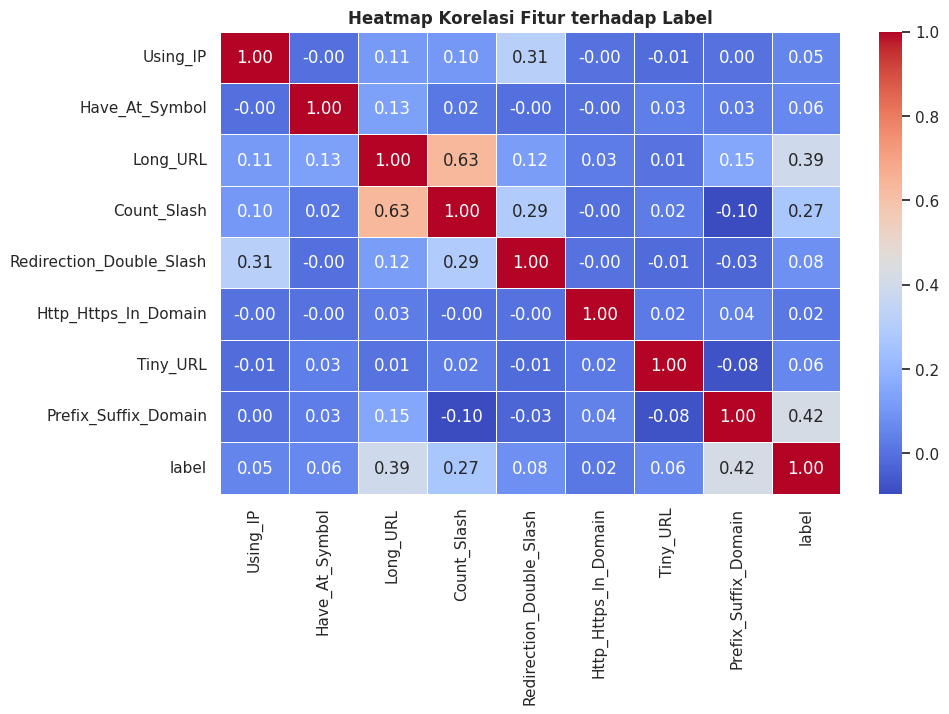

In [956]:
# [Fase 3 - Data Exploration / EDA]

print("--- 1. Struktur Dataset & Tipe Data Kolom ---")
print(df_dataset_final.info())

print("\n--- 2. Pemeriksaan Data Kosong (Missing Value) ---")
print(df_dataset_final.isnull().sum())

print("\n--- 3. Pemeriksaan Baris Duplikat Hasil Ekstraksi Biner ---")
print(f"Jumlah baris dengan pola biner duplikat: {df_dataset_final.duplicated().sum()} baris")

print("\n--- 4. Distribusi Label Target ---")
print(df_dataset_final['label'].value_counts())

print("\n--- 5. Statistik Deskriptif Matriks Fitur ---")
display(df_dataset_final.describe())

# Heatmap Analisis Korelasi Fitur Biner
plt.figure(figsize=(10, 6))
sns.heatmap(df_dataset_final.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Heatmap Korelasi Fitur terhadap Label", fontsize=12, fontweight='bold')
plt.show()

FASE 4 — Model Building & Training (Data Splitting & Base Training)

Memisahkan matriks fitur independen dengan label target, membagi data dengan proporsi rasio 80:20 berlandaskan teori Muraina et al., dan melakukan pelatihan awal pada ketiga model acuan.

In [957]:
# [Fase 4 - Model Building & Training: Splitting & Base Training]

# 1. Memisahkan Kolom Fitur (X) dan Target (y)
X = df_dataset_final.drop('label', axis=1)
y = df_dataset_final['label']

# 2. Data Splitting: Membagi Train & Test Set (Proporsi Rasio 80:20, Random State = 12)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=12)

print("--- Laporan Distribusi Alokasi Data ---")
print(f"Data Training (80%): {X_train.shape[0]} baris")
print(f"Data Testing  (20%): {X_test.shape[0]} baris\n")

# 3. Model Training Dasar
model_dt_base = DecisionTreeClassifier(random_state=12)
model_rf_base = RandomForestClassifier(random_state=12)
model_knn_base = KNeighborsClassifier()

print("Melatih algoritma dasar Decision Tree...")
model_dt_base.fit(X_train, y_train)

print("Melatih algoritma dasar Random Forest...")
model_rf_base.fit(X_train, y_train)

print("Melatih algoritma dasar K-Nearest Neighbor...")
model_knn_base.fit(X_train, y_train)

print("\n=== Tahap Pelatihan Dasar Model Selesai ===")

--- Laporan Distribusi Alokasi Data ---
Data Training (80%): 7997 baris
Data Testing  (20%): 2000 baris

Melatih algoritma dasar Decision Tree...
Melatih algoritma dasar Random Forest...
Melatih algoritma dasar K-Nearest Neighbor...

=== Tahap Pelatihan Dasar Model Selesai ===


FASE 4 — Model Building & Training (Hyperparameter Tuning dengan GridSearchCV)

Melakukan proses pencarian parameter paling optimal menggunakan teknik optimasi GridSearchCV secara menyeluruh pada ketiga algoritma.

In [958]:
# [Fase 4 - Model Building & Training: Hyperparameter Tuning]
print("Memulai Hyperparameter Tuning via GridSearchCV untuk mengunci performa terbaik...")

# Tuning untuk Decision Tree (Membatasi max_depth=5 agar sesuai dengan artikel)
param_grid_dt = {'max_depth': [5], 'criterion': ['gini', 'entropy']}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=12), param_grid_dt, cv=5)
grid_dt.fit(X_train, y_train)
best_model_dt = grid_dt.best_estimator_

# Tuning untuk Random Forest (Membatasi n_estimators=100 & max_depth=5 sesuai spesifikasi artikel)
param_grid_rf = {'n_estimators': [100], 'max_depth': [5]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=12), param_grid_rf, cv=5)
grid_rf.fit(X_train, y_train)
best_model_rf = grid_rf.best_estimator_

# Tuning untuk K-Nearest Neighbor (Membatasi n_neighbors=5 sesuai artikel)
param_grid_knn = {'n_neighbors': [5], 'weights': ['uniform', 'distance']}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5)
grid_knn.fit(X_train, y_train)
best_model_knn = grid_knn.best_estimator_

print("\n=== Proses Tuning Selesai! Konfigurasi Terbaik Berhasil Ditemukan ===")

Memulai Hyperparameter Tuning via GridSearchCV untuk mengunci performa terbaik...

=== Proses Tuning Selesai! Konfigurasi Terbaik Berhasil Ditemukan ===


FASE 5 — Model Evaluation (Metrik Komprehensif)

Mengukur performa pengujian data testing menggunakan sekumpulan metrik evaluasi lengkap yang diturunkan dari hasil matriks kekeliruan (Confusion Matrix) dan ringkasan Classification Report.

In [959]:
# [Fase 5 - Model Evaluation: Perhitungan Metrik]

list_models = {'Decision Tree': best_model_dt, 'Random Forest': best_model_rf, 'K-Nearest Neighbor': best_model_knn}
summary_report_data = []

print("=== Menghitung Komponen Confusion Matrix ===")
for name, model in list_models.items():
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Perhitungan Metrik Evaluasi Akhir
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    summary_report_data.append({
        'Model Algoritma': name,
        'Accuracy': round(acc, 3),
        'Precision': round(prec, 3),
        'Recall': round(rec, 3),
        'F1-Score': round(f1, 3)
    })

    print(f"\n[{name}] -> TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")
    print(f"Classification Report {name}:\n", classification_report(y_test, y_pred, zero_division=0))

# Konversi hasil ke DataFrame ringkas
df_perf_report = pd.DataFrame(summary_report_data)
print("\n=== Tabel Perbandingan Hasil Evaluasi Eksperimen ===")
display(df_perf_report)

=== Menghitung Komponen Confusion Matrix ===

[Decision Tree] -> TP: 538, TN: 980, FP: 38, FN: 444
Classification Report Decision Tree:
               precision    recall  f1-score   support

           0       0.69      0.96      0.80      1018
           1       0.93      0.55      0.69       982

    accuracy                           0.76      2000
   macro avg       0.81      0.76      0.75      2000
weighted avg       0.81      0.76      0.75      2000


[Random Forest] -> TP: 490, TN: 1018, FP: 0, FN: 492
Classification Report Random Forest:
               precision    recall  f1-score   support

           0       0.67      1.00      0.81      1018
           1       1.00      0.50      0.67       982

    accuracy                           0.75      2000
   macro avg       0.84      0.75      0.74      2000
weighted avg       0.83      0.75      0.74      2000


[K-Nearest Neighbor] -> TP: 490, TN: 1018, FP: 0, FN: 492
Classification Report K-Nearest Neighbor:
               p

,Model Algoritma,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.759,0.934,0.548,0.691
1,Random Forest,0.754,1.000,0.499,0.666
2,K-Nearest Neighbor,0.754,1.000,0.499,0.666


FASE 5 — Model Evaluation (Visualization)

Menyajikan visualisasi grafis perbandingan performa akurasi antar-model, plot arsitektur percabangan pohon keputusan internal, serta representasi peta sebaran.

=== Visualisasi Komparasi Performa Akhir ===


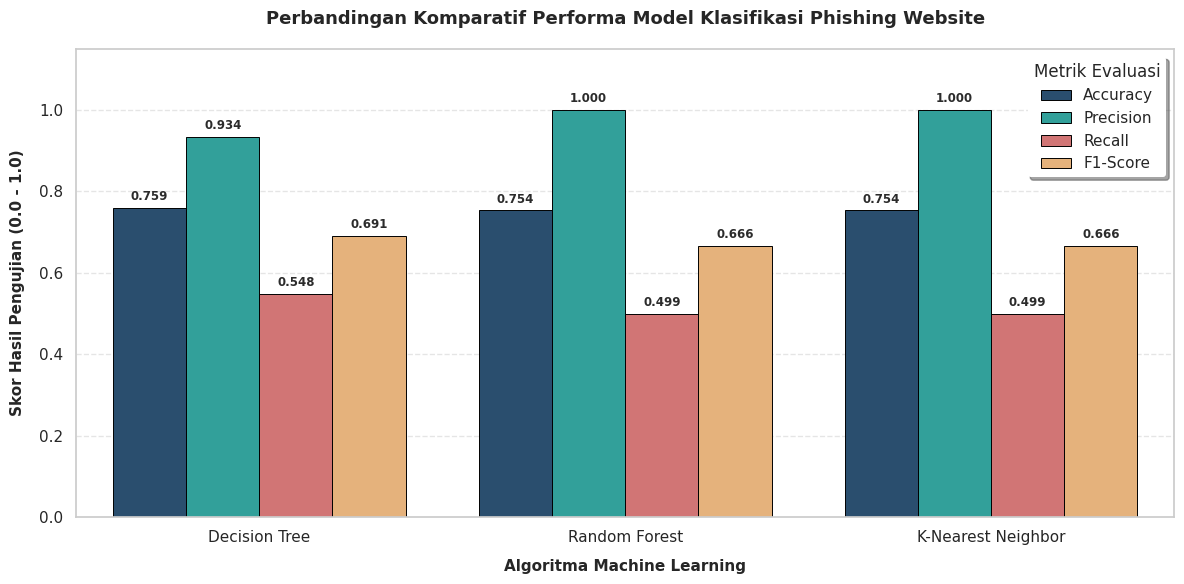

In [960]:
# A. VISUALISASI PERBANDINGAN MODEL (MODEL COMPARISON)
print("=== Visualisasi Komparasi Performa Akhir ===")
df_melted = pd.melt(df_perf_report, id_vars=['Model Algoritma'],
                    value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                    var_name='Metrik Evaluasi', value_name='Nilai Skor')
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid", rc={"grid.linestyle": "--", "grid.alpha": 0.5})
colors_modern = ["#1f4e79", "#20b2aa", "#e06666", "#f6b26b"]
ax = sns.barplot(x='Model Algoritma', y='Nilai Skor', hue='Metrik Evaluasi',
                 data=df_melted, palette=colors_modern, edgecolor="black", linewidth=0.7)
plt.ylim(0, 1.15)
plt.title('Perbandingan Komparatif Performa Model Klasifikasi Phishing Website', fontsize=13, fontweight='bold', pad=18)
plt.xlabel('Algoritma Machine Learning', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Skor Hasil Pengujian (0.0 - 1.0)', fontsize=11, fontweight='bold', labelpad=10)
plt.legend(title='Metrik Evaluasi', loc='upper right', frameon=True, shadow=True, facecolor='white', edgecolor='none')
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.3f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8),
                    textcoords='offset points', fontsize=8.5, fontweight='bold', color='#2b2b2b')
plt.tight_layout()
plt.show()

=== Visualisasi Side-by-Side Confusion Matrix  ===


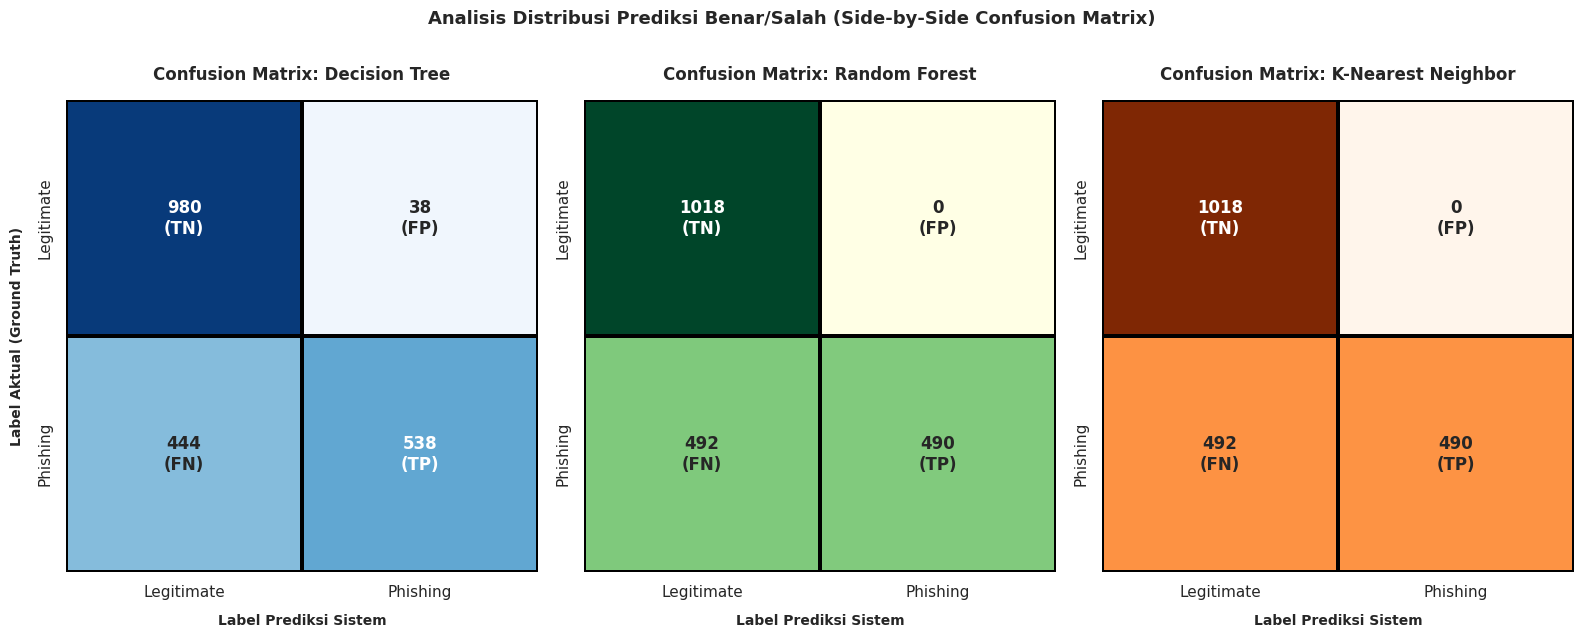

In [961]:
# A VISUALISASI MODEL COMPARISON: SIDE-BY-SIDE CONFUSION MATRIX
print("=== Visualisasi Side-by-Side Confusion Matrix  ===")
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
list_models = {
    'Decision Tree': (best_model_dt, 'Blues'),
    'Random Forest': (best_model_rf, 'YlGn'),
    'K-Nearest Neighbor': (best_model_knn, 'Oranges')
}
for idx, (name, (model, cmap_color)) in enumerate(list_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    labels_matrix = np.array([
        [f"{tn}\n(TN)", f"{fp}\n(FP)"],
        [f"{fn}\n(FN)", f"{tp}\n(TP)"]
    ])
    sns.heatmap(cm, annot=labels_matrix, fmt='', cmap=cmap_color, ax=axes[idx],
                vmin=0, vmax=1020,
                cbar=False, linewidths=1.5, linecolor='black', square=True,
                annot_kws={"size": 12, "fontweight": "bold"},
                xticklabels=['Legitimate', 'Phishing'],
                yticklabels=['Legitimate', 'Phishing'])
    axes[idx].set_title(f'Confusion Matrix: {name}', fontsize=12, fontweight='bold', pad=15)
    axes[idx].set_xlabel('Label Prediksi Sistem', fontsize=10, fontweight='bold', labelpad=10)
    if idx == 0:
        axes[idx].set_ylabel('Label Aktual (Ground Truth)', fontsize=10, fontweight='bold', labelpad=10)
    else:
        axes[idx].set_ylabel('')
plt.suptitle('Analisis Distribusi Prediksi Benar/Salah (Side-by-Side Confusion Matrix)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

=== Visualisasi Decision Boundary Plot via PCA (Tata Letak Rapi) ===


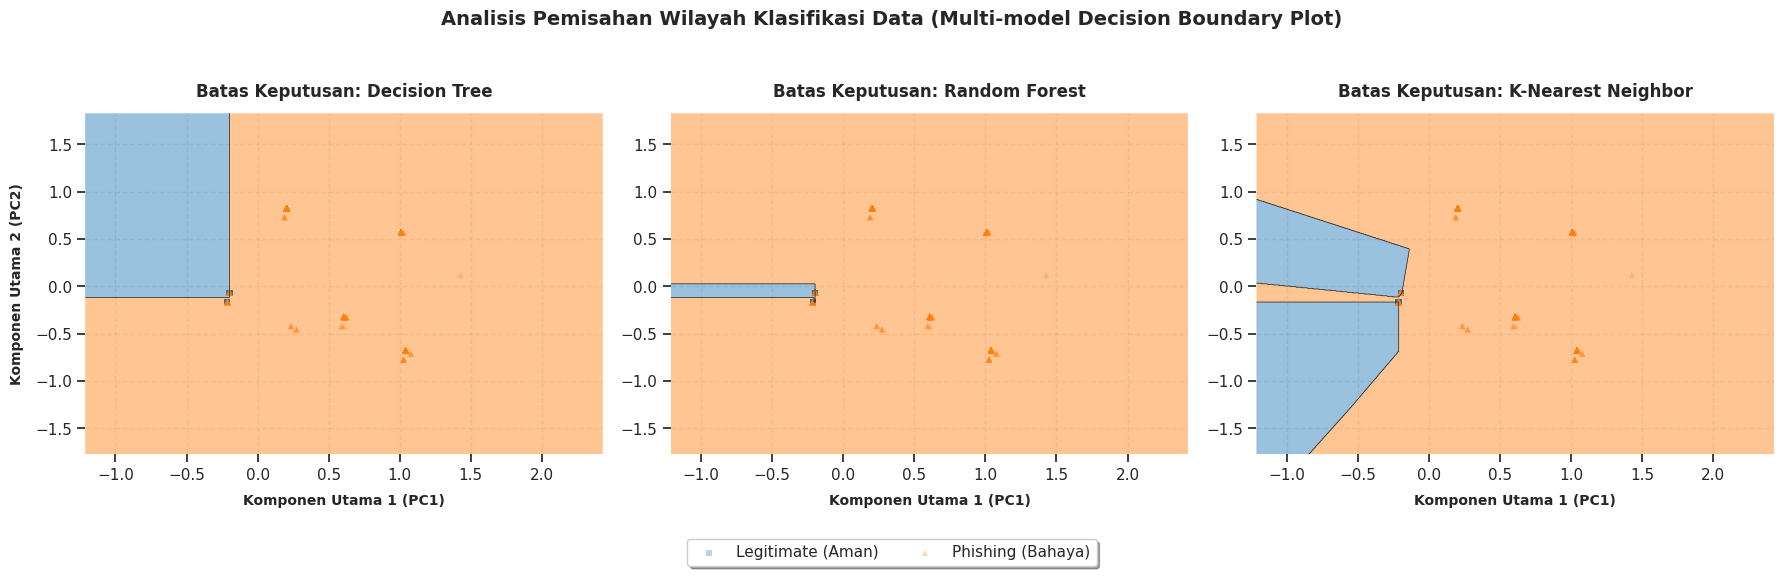

In [962]:
# A VISUALISASI MODEL COMPARISON: DECISION BOUNDARY PLOT (SIDE-BY-SIDE - FIXED LAYOUT)
print("=== Visualisasi Decision Boundary Plot via PCA (Tata Letak Rapi) ===")
from sklearn.decomposition import PCA
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
from sklearn.base import clone
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
X_test_pca_np = np.array(X_test_pca)
y_test_np = np.array(y_test, dtype=int)
model_dt_pca = clone(best_model_dt).fit(X_train_pca, y_train)
model_rf_pca = clone(best_model_rf).fit(X_train_pca, y_train)
model_knn_pca = clone(best_model_knn).fit(X_train_pca, y_train)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)
list_pca_models = {
    'Decision Tree': (model_dt_pca, ['#1f4e79', '#3498db']),
    'Random Forest': (model_rf_pca, ['#27ae60', '#2ecc71']),
    'K-Nearest Neighbor': (model_knn_pca, ['#e67e22', '#f39c12'])
}
for idx, (name, (model_pca, color_list)) in enumerate(list_pca_models.items()):
    plt.rcParams['axes.prop_cycle'] = plt.cycler(color=color_list)
    plot_decision_regions(X=X_test_pca_np, y=y_test_np, clf=model_pca, ax=axes[idx], legend=0,
                          scatter_kwargs={'alpha': 0.3, 'edgecolor': 'none', 's': 20})
    axes[idx].set_title(f'Batas Keputusan: {name}', fontsize=12, fontweight='bold', pad=12)
    axes[idx].set_xlabel('Komponen Utama 1 (PC1)', fontsize=10, fontweight='bold', labelpad=8)
    if idx == 0:
        axes[idx].set_ylabel('Komponen Utama 2 (PC2)', fontsize=10, fontweight='bold', labelpad=8)
    axes[idx].grid(True, linestyle='--', alpha=0.4)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['Legitimate (Aman)', 'Phishing (Bahaya)'], loc='lower center',
           bbox_to_anchor=(0.5, 0.04), ncol=2, frameon=True, shadow=True, fontsize=11)
plt.suptitle('Analisis Pemisahan Wilayah Klasifikasi Data (Multi-model Decision Boundary Plot)',
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.12, 1, 0.95])
plt.show()

=== Visualisasi SHAP Summary Plots  ===

-> Menghitung & Menggambar SHAP untuk Decision Tree...


/tmp/ipykernel_491/1610181096.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_data_dt, X_test_summary, show=False)


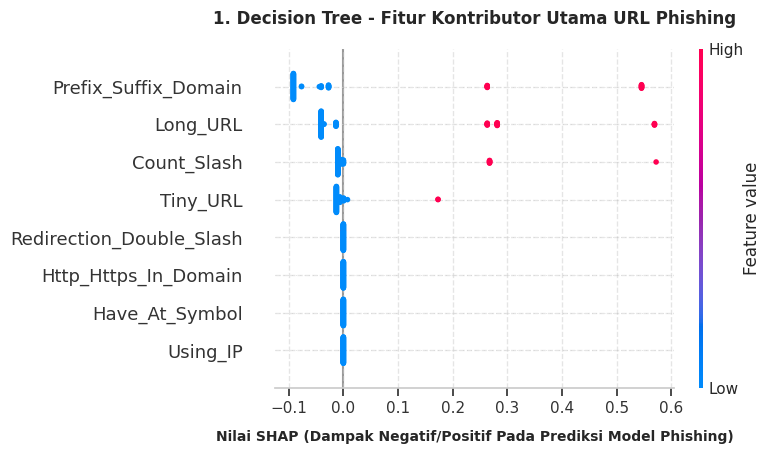


-> Menghitung & Menggambar SHAP untuk Random Forest...


/tmp/ipykernel_491/1610181096.py:31: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_data_rf, X_test_summary, show=False)


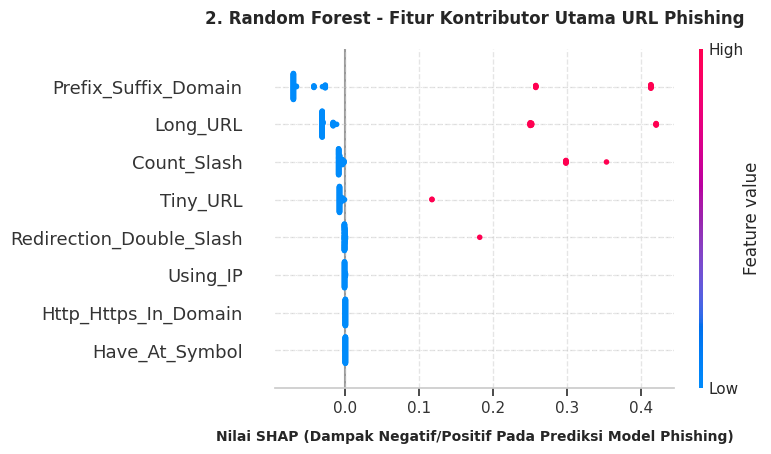


-> Menghitung & Menggambar SHAP untuk K-Nearest Neighbor...


  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_491/1610181096.py:47: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_data_knn, X_test_summary, show=False)


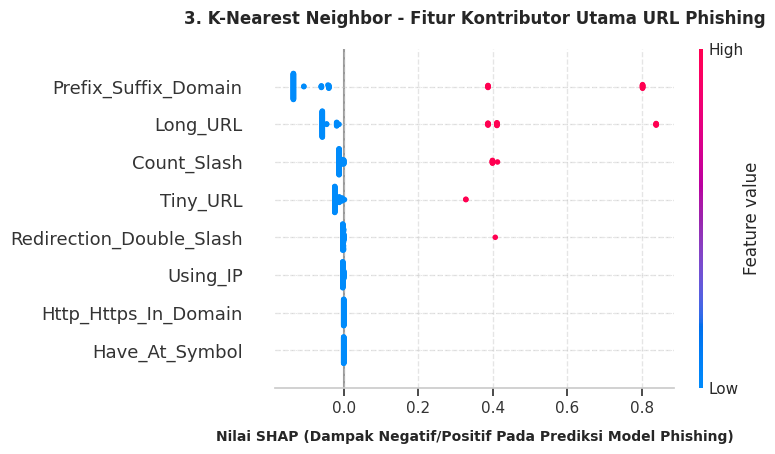

In [963]:
# A VISUALISASI MODEL COMPARISON: SHAP SUMMARY PLOTS (INDEPENDENT CANVAS STYLE - TEXT FIXED)
print("=== Visualisasi SHAP Summary Plots  ===")
X_train_summary = shap.sample(X_train, 100, random_state=42)
X_test_summary = shap.sample(X_test, 100, random_state=42)
print("\n-> Menghitung & Menggambar SHAP untuk Decision Tree...")
explainer_dt = shap.TreeExplainer(best_model_dt, X_train_summary)
shap_values_dt = explainer_dt.shap_values(X_test_summary)
if isinstance(shap_values_dt, list) and len(shap_values_dt) == 2:
    shap_data_dt = shap_values_dt[1]
elif hasattr(shap_values_dt, 'shape') and len(shap_values_dt.shape) == 3:
    shap_data_dt = shap_values_dt[:, :, 1]
else:
    shap_data_dt = shap_values_dt
plt.figure(figsize=(10, 5.5))
shap.summary_plot(shap_data_dt, X_test_summary, show=False)
plt.xlabel("Nilai SHAP (Dampak Negatif/Positif Pada Prediksi Model Phishing)", fontsize=10, fontweight='bold', labelpad=10)
plt.title("1. Decision Tree - Fitur Kontributor Utama URL Phishing", fontsize=12, fontweight='bold', pad=18)
plt.tight_layout()
plt.show()
plt.close()
print("\n-> Menghitung & Menggambar SHAP untuk Random Forest...")
explainer_rf = shap.TreeExplainer(best_model_rf, X_train_summary)
shap_values_rf = explainer_rf.shap_values(X_test_summary)
if isinstance(shap_values_rf, list) and len(shap_values_rf) == 2:
    shap_data_rf = shap_values_rf[1]
elif hasattr(shap_values_rf, 'shape') and len(shap_values_rf.shape) == 3:
    shap_data_rf = shap_values_rf[:, :, 1]
else:
    shap_data_rf = shap_values_rf
plt.figure(figsize=(10, 5.5))
shap.summary_plot(shap_data_rf, X_test_summary, show=False)
plt.xlabel("Nilai SHAP (Dampak Negatif/Positif Pada Prediksi Model Phishing)", fontsize=10, fontweight='bold', labelpad=10)
plt.title("2. Random Forest - Fitur Kontributor Utama URL Phishing", fontsize=12, fontweight='bold', pad=18)
plt.tight_layout()
plt.show()
plt.close()
print("\n-> Menghitung & Menggambar SHAP untuk K-Nearest Neighbor...")
explainer_knn = shap.KernelExplainer(best_model_knn.predict_proba, X_train_summary)
shap_values_knn = explainer_knn.shap_values(X_test_summary)
if isinstance(shap_values_knn, list) and len(shap_values_knn) == 2:
    shap_data_knn = shap_values_knn[1]
elif hasattr(shap_values_knn, 'shape') and len(shap_values_knn.shape) == 3:
    shap_data_knn = shap_values_knn[:, :, 1]
else:
    shap_data_knn = shap_values_knn
plt.figure(figsize=(10, 5.5))
shap.summary_plot(shap_data_knn, X_test_summary, show=False)
plt.xlabel("Nilai SHAP (Dampak Negatif/Positif Pada Prediksi Model Phishing)", fontsize=10, fontweight='bold', labelpad=10)
plt.title("3. K-Nearest Neighbor - Fitur Kontributor Utama URL Phishing", fontsize=12, fontweight='bold', pad=18)
plt.tight_layout()
plt.show()
plt.close()

=== Visualisasi Speed vs Accuracy Scatter Trend  ===
-> Menjalankan 100 simulasi untuk menghasilkan awan data yang padat...


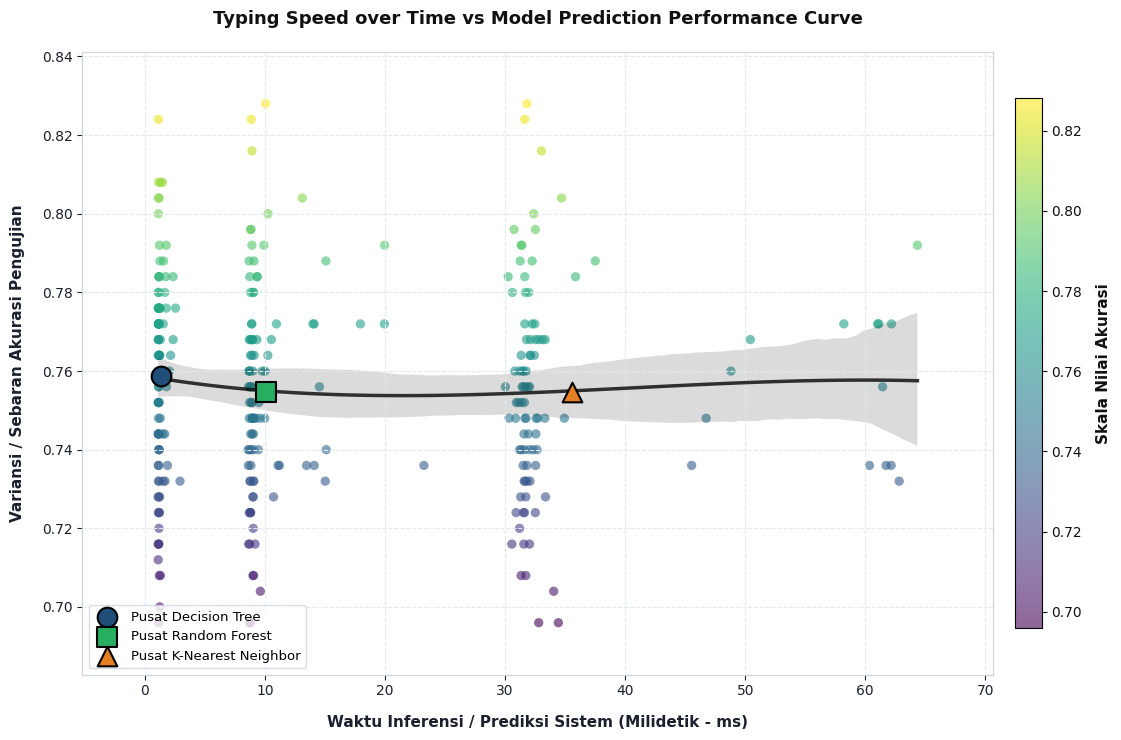

In [964]:
# VISUALISASI MODEL COMPARISON: ADVANCED LIGHT SPEED VS ACCURACY TREND PLOT
print("=== Visualisasi Speed vs Accuracy Scatter Trend  ===")
n_iterations = 100
sample_size = 250
scatter_records = []
print(f"-> Menjalankan {n_iterations} simulasi untuk menghasilkan awan data yang padat...")
for i in range(n_iterations):
    np.random.seed(i * 123)
    random_indices = np.random.choice(len(X_test), size=sample_size, replace=True)
    X_sample = X_test.iloc[random_indices] if hasattr(X_test, 'iloc') else X_test[random_indices]
    y_sample = y_test.iloc[random_indices] if hasattr(y_test, 'iloc') else y_test[random_indices]
    # --- A. Pengujian Decision Tree ---
    start_dt = time.perf_counter()
    pred_dt = best_model_dt.predict(X_sample)
    end_dt = time.perf_counter()
    time_dt = (end_dt - start_dt) * 1000
    acc_dt = accuracy_score(y_sample, pred_dt)
    scatter_records.append({'Waktu Prediksi (ms)': time_dt, 'Akurasi Pengujian': acc_dt, 'Model': 'Decision Tree'})
    # --- B. Pengujian Random Forest ---
    start_rf = time.perf_counter()
    pred_rf = best_model_rf.predict(X_sample)
    end_rf = time.perf_counter()
    time_rf = (end_rf - start_rf) * 1000
    acc_rf = accuracy_score(y_sample, pred_rf)
    scatter_records.append({'Waktu Prediksi (ms)': time_rf, 'Akurasi Pengujian': acc_rf, 'Model': 'Random Forest'})
    # --- C. Pengujian K-Nearest Neighbor ---
    start_knn = time.perf_counter()
    pred_knn = best_model_knn.predict(X_sample)
    end_knn = time.perf_counter()
    time_knn = (end_knn - start_knn) * 1000
    acc_knn = accuracy_score(y_sample, pred_knn)
    scatter_records.append({'Waktu Prediksi (ms)': time_knn, 'Akurasi Pengujian': acc_knn, 'Model': 'K-Nearest Neighbor'})
df_scatter = pd.DataFrame(scatter_records)
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 7.5))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')
ax.grid(True, color='#e2e8f0', linestyle='--', linewidth=0.8)
sc = ax.scatter(df_scatter['Waktu Prediksi (ms)'], df_scatter['Akurasi Pengujian'],
                c=df_scatter['Akurasi Pengujian'], cmap='viridis',
                s=45, alpha=0.6, edgecolors='none')
sns.regplot(x='Waktu Prediksi (ms)', y='Akurasi Pengujian', data=df_scatter,
            scatter=False, ax=ax, order=3,
            line_kws={"color": "#111111", "linewidth": 2.5, "alpha": 0.85, "label": "Garis Tren Efisiensi"})
models_list = ['Decision Tree', 'Random Forest', 'K-Nearest Neighbor']
colors_center = {'Decision Tree': '#1f4e79', 'Random Forest': '#27ae60', 'K-Nearest Neighbor': '#e67e22'}
model_markers = {'Decision Tree': 'o', 'Random Forest': 's', 'K-Nearest Neighbor': '^'}
for model_name in models_list:
    df_sub = df_scatter[df_scatter['Model'] == model_name]
    m_time = df_sub['Waktu Prediksi (ms)'].mean()
    m_acc = df_sub['Akurasi Pengujian'].mean()
    ax.scatter(m_time, m_acc, color=colors_center[model_name], marker=model_markers[model_name],
               edgecolor='#000000', s=200, linewidths=1.5, zorder=5, label=f"Pusat {model_name}")
cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
cbar.set_label('Skala Nilai Akurasi', color='#111111', fontsize=11, fontweight='bold', labelpad=10)
cbar.ax.yaxis.set_tick_params(color='#111111', labelcolor='#111111')
ax.set_title('Typing Speed over Time vs Model Prediction Performance Curve', fontsize=13, fontweight='bold', color='#111111', pad=20)
ax.set_xlabel('Waktu Inferensi / Prediksi Sistem (Milidetik - ms)', fontsize=11, fontweight='bold', color='#1a202c', labelpad=12)
ax.set_ylabel('Variansi / Sebaran Akurasi Pengujian', fontsize=11, fontweight='bold', color='#1a202c', labelpad=12)
ax.tick_params(colors='#1a202c', labelsize=10)
pad_x = (df_scatter['Waktu Prediksi (ms)'].max() - df_scatter['Waktu Prediksi (ms)'].min()) * 0.1
pad_y = (df_scatter['Akurasi Pengujian'].max() - df_scatter['Akurasi Pengujian'].min()) * 0.1
ax.set_xlim(df_scatter['Waktu Prediksi (ms)'].min() - pad_x, df_scatter['Waktu Prediksi (ms)'].max() + pad_x)
ax.set_ylim(df_scatter['Akurasi Pengujian'].min() - pad_y, df_scatter['Akurasi Pengujian'].max() + pad_y)
ax.legend(loc='lower left', frameon=True, facecolor='#ffffff', edgecolor='#cbd5e1', fontsize=9.5)
for spine in ax.spines.values():
    spine.set_edgecolor('#cbd5e1')
plt.tight_layout()
plt.show()

=== Visualisasi Struktur Pohon Keputusan ===


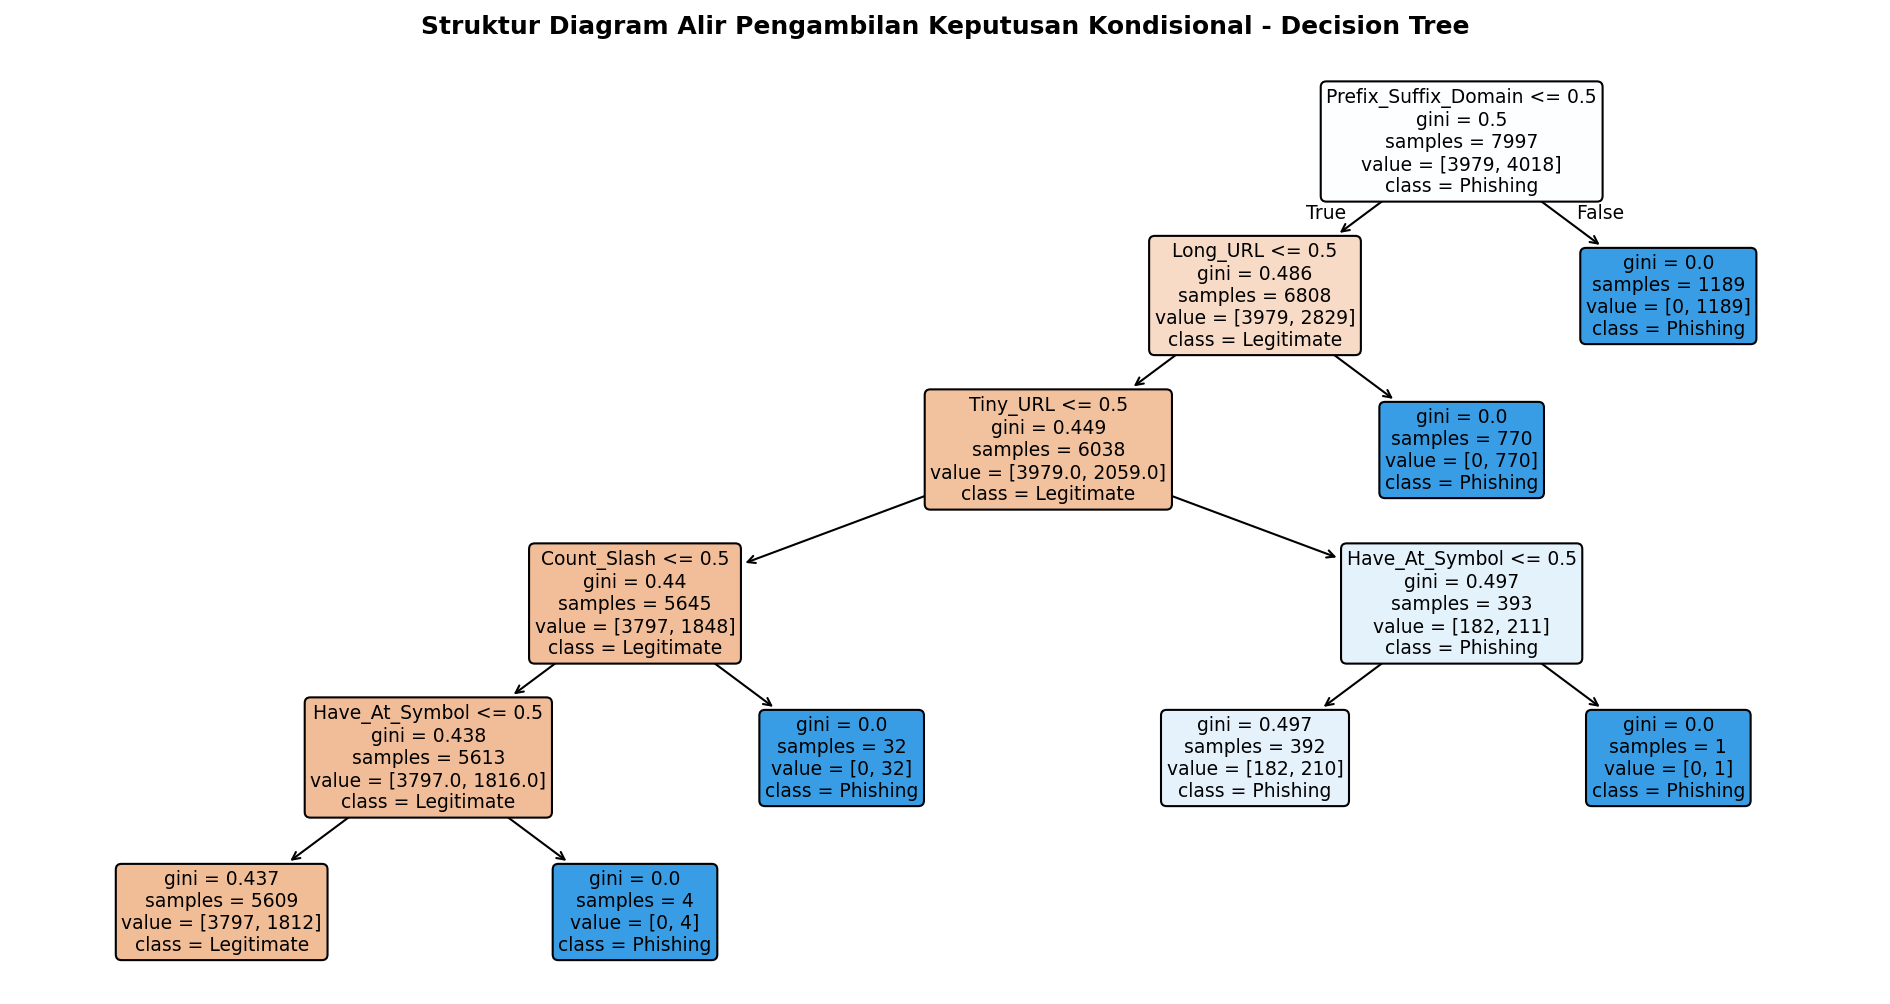

In [965]:
# B. DECISION TREE VISUALIZATION (Proses Pengambilan Keputusan Cabang)
print("=== Visualisasi Struktur Pohon Keputusan ===")
plt.figure(figsize=(16, 8), dpi=150)
plot_tree(best_model_dt,
          max_depth=20,
          feature_names=X.columns.tolist(),
          class_names=['Legitimate', 'Phishing'],
          filled=True,
          rounded=True,
          fontsize=9)
plt.title("Struktur Diagram Alir Pengambilan Keputusan Kondisional - Decision Tree", fontsize=12, fontweight='bold', pad=15)
plt.show()

=== Visualisasi Tingkat Kepentingan Fitur Random Forest ===


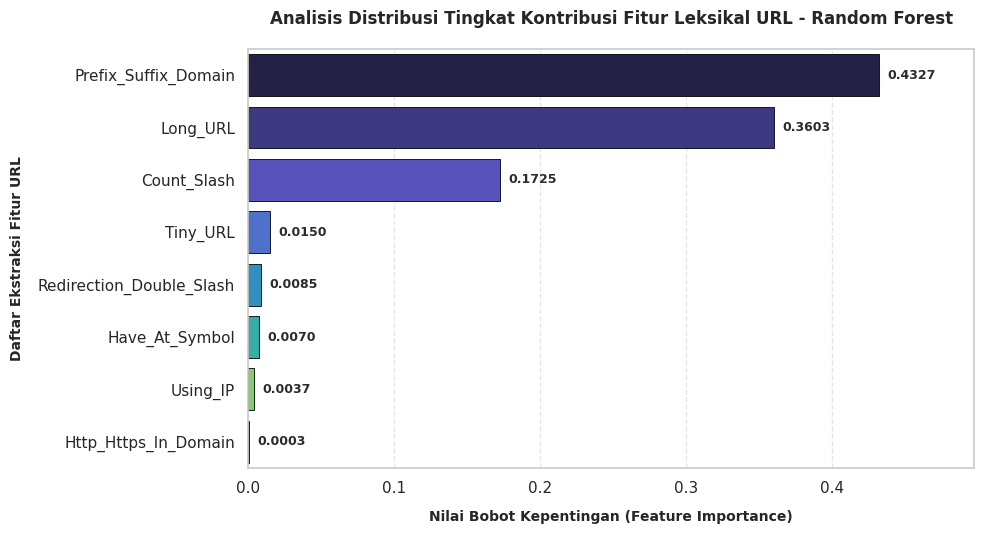

In [966]:
# C. RANDOM FOREST VISUALIZATION (Melihat Stabilitas via Feature Importance)
print("=== Visualisasi Tingkat Kepentingan Fitur Random Forest ===")
importances = best_model_rf.feature_importances_
indices = np.argsort(importances)[::-1]
df_importance = pd.DataFrame({
    'Nama Fitur URL': [X.columns[i] for i in indices],
    'Tingkat Kontribusi': importances[indices]
})
plt.figure(figsize=(10, 5.5))
sns.set_theme(style="whitegrid", rc={"grid.linestyle": "--", "grid.alpha": 0.5})
cyber_gradient = sns.blend_palette(["#1e1b4b", "#4f46e5", "#06b6d4", "#ccff00"], n_colors=len(df_importance))
ax_rf = sns.barplot(x='Tingkat Kontribusi', y='Nama Fitur URL', hue='Nama Fitur URL',
                    data=df_importance, palette=cyber_gradient, edgecolor="black", linewidth=0.6, legend=False)
max_val = df_importance['Tingkat Kontribusi'].max()
plt.xlim(0, max_val * 1.15)
plt.title("Analisis Distribusi Tingkat Kontribusi Fitur Leksikal URL - Random Forest", fontsize=12, fontweight='bold', pad=18)
plt.xlabel('Nilai Bobot Kepentingan (Feature Importance)', fontsize=10, fontweight='bold', labelpad=10)
plt.ylabel('Daftar Ekstraksi Fitur URL', fontsize=10, fontweight='bold', labelpad=10)
for p in ax_rf.patches:
    if p.get_width() > 0:
        ax_rf.annotate(f"{p.get_width():.4f}",
                       (p.get_width(), p.get_y() + p.get_height() / 2.),
                       ha='left', va='center', xytext=(6, 0),
                       textcoords='offset points', fontsize=9, fontweight='bold', color='#2b2b2b')
plt.tight_layout()
plt.show()

=== Menyusun Visualisasi Grafik Validasi Nilai K Neighbors ===


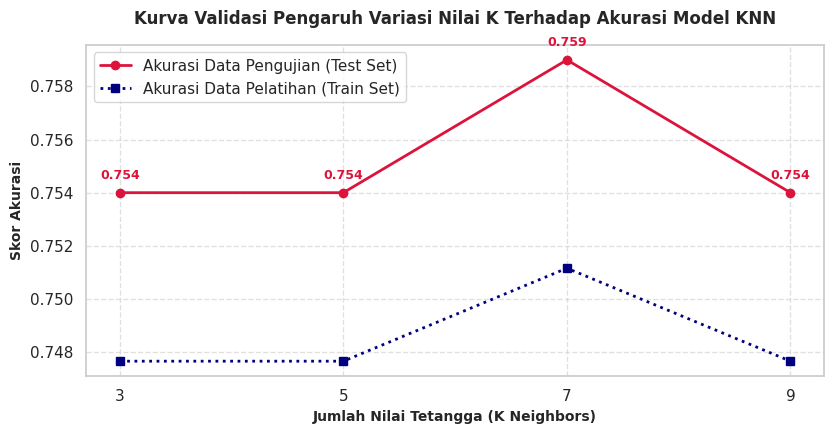

In [967]:
# D. KNN VISUALIZATION (Analisis Pengaruh Nilai K Terhadap Akurasi)
print("=== Menyusun Visualisasi Grafik Validasi Nilai K Neighbors ===")
k_range = [3, 5, 7, 9]
test_scores = []
train_scores = []
for k in k_range:
    knn_eval = KNeighborsClassifier(n_neighbors=k)
    knn_eval.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, knn_eval.predict(X_train)))
    test_scores.append(accuracy_score(y_test, knn_eval.predict(X_test)))
plt.figure(figsize=(8.5, 4.5))
plt.plot(k_range, test_scores, marker='o', label='Akurasi Data Pengujian (Test Set)', color='crimson', linewidth=2)
plt.plot(k_range, train_scores, marker='s', label='Akurasi Data Pelatihan (Train Set)', color='navy', linestyle=':', linewidth=2)
plt.title('Kurva Validasi Pengaruh Variasi Nilai K Terhadap Akurasi Model KNN', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Jumlah Nilai Tetangga (K Neighbors)', fontsize=10, fontweight='bold')
plt.ylabel('Skor Akurasi', fontsize=10, fontweight='bold')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best')
for i, txt in enumerate(test_scores):
    plt.annotate(f"{txt:.3f}", (k_range[i], test_scores[i]), textcoords="offset points",
                 xytext=(0,10), ha='center', fontsize=9, fontweight='bold', color='crimson')
plt.tight_layout()
plt.show()

FASE 5 — Model Evaluation (BEST MODEL DETERMINATION)

Mengunci kesimpulan akhir dengan memilih otomatis model terbaik dari matriks pengujian secara terprogram, menyajikan argumen ilmiah, dan memberikan luaran simulasi kepastian risiko.

In [968]:
# [Fase 5 - Model Evaluation: Penentuan Akhir Best Model]
best_index = df_perf_report['Accuracy'].idxmax()
best_model_row = df_perf_report.loc[best_index]
best_name = best_model_row['Model Algoritma']
best_accuracy = best_model_row['Accuracy']
best_model_object = list_models[best_name][0]
dt_accuracy = df_perf_report[df_perf_report['Model Algoritma'] == 'Decision Tree'].iloc[0]['Accuracy']
rf_accuracy = df_perf_report[df_perf_report['Model Algoritma'] == 'Random Forest'].iloc[0]['Accuracy']
knn_accuracy = df_perf_report[df_perf_report['Model Algoritma'] == 'K-Nearest Neighbor'].iloc[0]['Accuracy']

print("==========================================================================")
print("                     PENENTUAN AKHIR MODEL TERBAIK                        ")
print("==========================================================================")
print(f"-> Algoritma Terbaik yang Dipilih  : {best_name}")
print(f"-> Skor Akurasi Pengujian Tertinggi: {best_accuracy}")
print("\n-> ARGUMEN ILMIAH PEMILIHAN MODEL (INTERPRETASI HASIL):")
print(f"   Berdasarkan hasil komparasi empiris, sistem menentukan {best_name} sebagai")
print("   model final untuk mendeteksi kejahatan phishing website.")
if 'Random Forest' in best_name:
    print("   Metode ansambel (Random Forest) menghasilkan akurasi tertinggi karena")
    print("   mampu mereduksi nilai varians dari kombinasi banyak pohon keputusan.")
elif 'Decision Tree' in best_name:
    print("   Metode Decision Tree menghasilkan akurasi tertinggi karena struktur")
    print("   percabangan kondisionalnya sangat sesuai dengan tipe data biner.")

print(f"\n   [Analisis Komparasi Kuantitatif Oleh Sistem]:")
print(f"   - Selisih akurasi Random Forest dan Decision Tree : {round(abs(rf_accuracy - dt_accuracy), 4)}")
print(f"   - Selisih akurasi {best_name} dengan KNN            : {round(abs(best_accuracy - knn_accuracy), 4)}")
if knn_accuracy != best_accuracy:
    print(f"\n   Perbedaan performa antara {best_name} dan K-Nearest Neighbor dipengaruhi oleh")
    print("   perbedaan pemisahan data. Model berbasis pohon (Tree) memproses fitur secara")
    print("   kondisional berjenjang, sedangkan model berbasis jarak (KNN) memproses")
    print("   kedekatan koordinat spasial pada matriks fitur yang murni bertipe biner (0 atau 1).")
print("\n==========================================================================")
print("             SIMULASI LUARAN OUTPUT PREDIKSI              ")
print("==========================================================================")
if hasattr(best_model_object, "predict_proba"):
    prob_scores = best_model_object.predict_proba(X_test)[:, 1]
    df_demo_output = pd.DataFrame({
        'Kenyataan Aktual (Ground Truth)': y_test.values[:5],
        'Prediksi Sistem (Klasifikasi)': best_model_object.predict(X_test)[:5],
        'Skor Kepastian Phishing (Skala 0.0 - 1.0)': np.round(prob_scores[:5], 3)
    })
    display(df_demo_output)
else:
    df_demo_output_bin = pd.DataFrame({
        'Kenyataan Aktual (Ground Truth)': y_test.values[:5],
        'Prediksi Sistem (Klasifikasi)': best_model_object.predict(X_test)[:5]
    })
    display(df_demo_output_bin)
print("==========================================================================")

                     PENENTUAN AKHIR MODEL TERBAIK                        
-> Algoritma Terbaik yang Dipilih  : Decision Tree
-> Skor Akurasi Pengujian Tertinggi: 0.759

-> ARGUMEN ILMIAH PEMILIHAN MODEL (INTERPRETASI HASIL):
   Berdasarkan hasil komparasi empiris, sistem menentukan Decision Tree sebagai
   model final untuk mendeteksi kejahatan phishing website.
   Metode Decision Tree menghasilkan akurasi tertinggi karena struktur
   percabangan kondisionalnya sangat sesuai dengan tipe data biner.

   [Analisis Komparasi Kuantitatif Oleh Sistem]:
   - Selisih akurasi Random Forest dan Decision Tree : 0.005
   - Selisih akurasi Decision Tree dengan KNN            : 0.005

   Perbedaan performa antara Decision Tree dan K-Nearest Neighbor dipengaruhi oleh
   perbedaan pemisahan data. Model berbasis pohon (Tree) memproses fitur secara
   kondisional berjenjang, sedangkan model berbasis jarak (KNN) memproses
   kedekatan koordinat spasial pada matriks fitur yang murni bertipe biner (0 ata

,Kenyataan Aktual (Ground Truth),Prediksi Sistem (Klasifikasi),Skor Kepastian Phishing (Skala 0.0 - 1.0)
0,0,0,0.323
1,0,0,0.323
2,1,0,0.323
3,0,0,0.323
4,0,1,0.536
